In [1]:
from PIL import Image

In [2]:
import numpy as np

In [3]:
import importlib
import image_builder
importlib.reload(image_builder)

<module 'image_builder' from '/Users/anthonyliu/Projects/receipt-printer-exquisite-corpse/src/image_builder.py'>

# Load content

In [4]:
import sqlite3
import db
import form_parser

In [10]:
from io import BytesIO

In [11]:
import cv2

In [12]:
import numpy as np

In [13]:
conn = sqlite3.connect('../test-other.db')

In [14]:
db_img_bytes = db.get_drawing(conn, 1)[4]

In [15]:
zz = Image.open(BytesIO(db_img_bytes))

In [16]:
w, h = zz.size

In [17]:
text_array.shape

NameError: name 'text_array' is not defined

In [129]:
def crop(a, pad_x, pad_y, min_x):
    is_black = a < 255
    
    h, w = a.shape
    
    x_0 = is_black.max(axis=0).tolist().index(True)
    x_1 = w - is_black.max(axis=0)[::-1].tolist().index(True) 
    y_0 = is_black.max(axis=1).tolist().index(True)
    y_1 = h - is_black.max(axis=1)[::-1].tolist().index(True)

    if x_1 - x_0 < min_x:
        x_1 = x_0 + min_x
    
    return a[
        :, # np.clip(y_0 - pad_y, 0, h):np.clip(y_1 + pad_y, 0, h),
        np.clip(x_0 - pad_x, 0, w):np.clip(x_1 + pad_x, 0, w),
        ]

In [18]:
from IPython.display import display

In [19]:
import importlib
import image_builder
importlib.reload(image_builder)

<module 'image_builder' from '/Users/anthonyliu/Projects/receipt-printer-exquisite-corpse/src/image_builder.py'>

In [24]:
from rcprinter_client import RCPrinterClient

In [25]:
annos = [
    "Rachel Vincent Petacat (she) (Faculty)",
    "Benedict Cumberbatch Benedict Cumberbatch (he) (W2'26)",
    "Tony Liu (he) (SP2'26)",
    "TP Wong (he) (SP2'26)",
    "Hong Anh Vu (he) (SP2'26)",
]

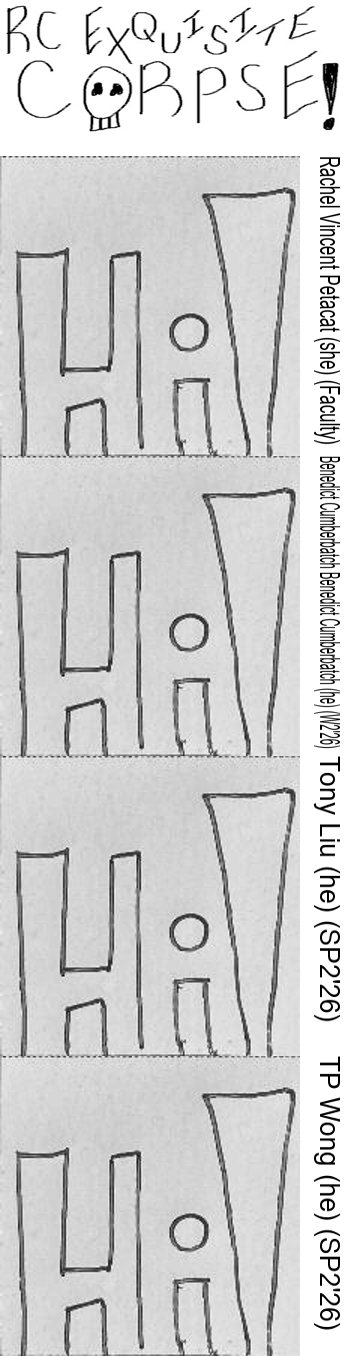

In [28]:
zzz = image_builder.get_completed_game([zz] * 4, annos[:4])
Image.fromarray(zzz)

In [29]:
RCPrinterClient().send_image(Image.fromarray(zzz))

Exception: Image too large; must be under 65500

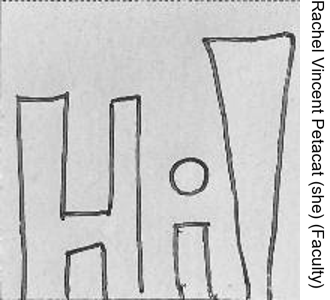

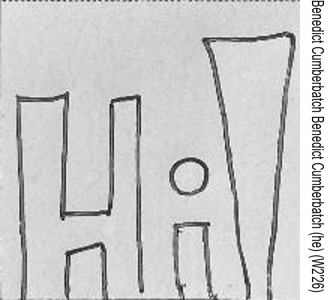

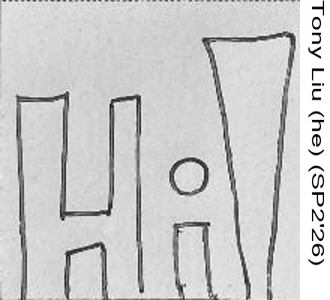

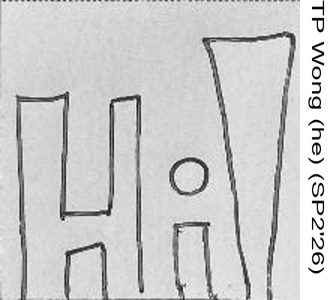

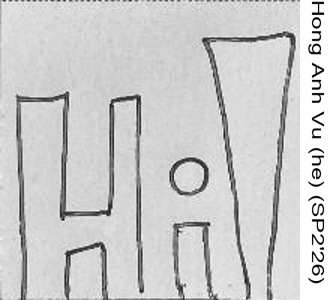

In [139]:
a = []
for nm in [
    "Rachel Vincent Petacat (she) (Faculty)",
    "Benedict Cumberbatch Benedict Cumberbatch (he) (W2'26)",
    "Tony Liu (he) (SP2'26)",
    "TP Wong (he) (SP2'26)",
    "Hong Anh Vu (he) (SP2'26)",
]:
    text_array = image_builder.get_text(
        nm,
        image_builder.PATH_TO_FONT, 28, (50, 1000), (0, 0))
    text_as_image = Image.fromarray(crop(text_array, 20, 8, 300)).resize((300, 30))
    # text_as_image = Image.fromarray(text_array)

    z = np.hstack([np.array(zz.resize((300, 300))), np.array(text_as_image.transpose(Image.Transpose.ROTATE_270))])
    a.append(z)
    display(Image.fromarray(z))

In [96]:
Image.fromarray(text_array)

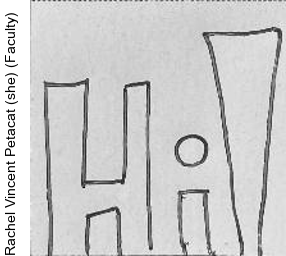

In [51]:
Image.fromarray(np.hstack([
    np.array(text_as_image.transpose(Image.Transpose.ROTATE_90)),
    np.array(zz.resize((256, 256))),
]))